#**TelecomX parte 2 Latam**

##Extracción del Archivo Tratado

In [ ]:
import pandas as pd

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
datos = pd.read_pickle('/content/datos_limpios.pkl')

In [ ]:
datos.head()

,abandono,genero,adulto_mayor,tiene_pareja,dependientes,meses_cliente,servicio_telefono,lineas_multiples,seguridad_online,respaldo_online,...,cargo_total,cuentas_diarias,cantidad_servicios,servicio_internet_Fiber optic,servicio_internet_No,tipo_contrato_One year,tipo_contrato_Two year,metodo_pago_Credit card (automatic),metodo_pago_Electronic check,metodo_pago_Mailed check
0,0.0,0,0,1,1,9,1,0,0,1,...,593.30,2.19,1,0,0,1,0,0,0,1
1,0.0,1,0,0,0,9,1,1,0,0,...,542.40,2.00,0,0,0,0,0,0,0,1
2,1.0,1,0,0,0,4,1,0,0,0,...,280.85,2.46,0,1,0,0,0,0,1,0
3,1.0,1,1,1,0,13,1,0,0,1,...,1237.85,3.27,1,1,0,0,0,0,1,0
4,1.0,0,1,1,0,3,1,0,0,0,...,267.40,2.80,0,1,0,0,0,0,0,1


In [ ]:
datos['abandono'].value_counts()

,count
abandono,
0.0,5174
1.0,1869


In [ ]:
datos.corr()['abandono'].sort_values(ascending=True)

,abandono
meses_cliente,-0.352229
tipo_contrato_Two year,-0.302253
servicio_internet_No,-0.227890
cargo_total,-0.198324
tipo_contrato_One year,-0.177820
seguridad_online,-0.171226
soporte_tecnico,-0.164674
dependientes,-0.164221
cantidad_servicios,-0.156778
tiene_pareja,-0.150448


In [ ]:
df_modelo = datos[
    [
        'abandono',
        'meses_cliente',
        'tipo_contrato_Two year',
        'servicio_internet_No',
        'cargo_total',
        'tipo_contrato_One year',
        'seguridad_online',
        'soporte_tecnico',
        'dependientes',
        'cantidad_servicios',
        'tiene_pareja',
        'adulto_mayor',
        'facturacion_electronica',
        'cargo_mensual',
        'cuentas_diarias',
        'metodo_pago_Electronic check'
    ]
]

In [ ]:
datos.shape[1]

26

In [ ]:
df_modelo.shape[1]

16

In [ ]:
import numpy as np

def ancho_bin(df,columna):
  q75,q25 = np.percentile(df[columna],[75,25])
  iqr = q75-q25
  ancho = 2 * iqr * np.power(len(df[columna]), -1/3)
  return ancho

In [ ]:
abandono_promedio = df_modelo['abandono'].mean()
abandono_mediana = df_modelo['abandono'].median()

##Verificación de la Proporción de Cancelación (Churn)

In [ ]:
(datos['abandono'].value_counts(normalize=True) * 100).round(2)

,proportion
abandono,
0.0,73.46
1.0,26.54


Al analizar la variable abandono, se observa la siguiente proporción de clientes:

* 73,46% de los clientes no cancelaron el servicio (clientes activos).

* 26,54% de los clientes sí cancelaron el servicio.

Esto indica que la mayoría de los clientes permanece en la empresa, mientras que aproximadamente una cuarta parte de los clientes abandona el servicio.

##Análisis de Correlación

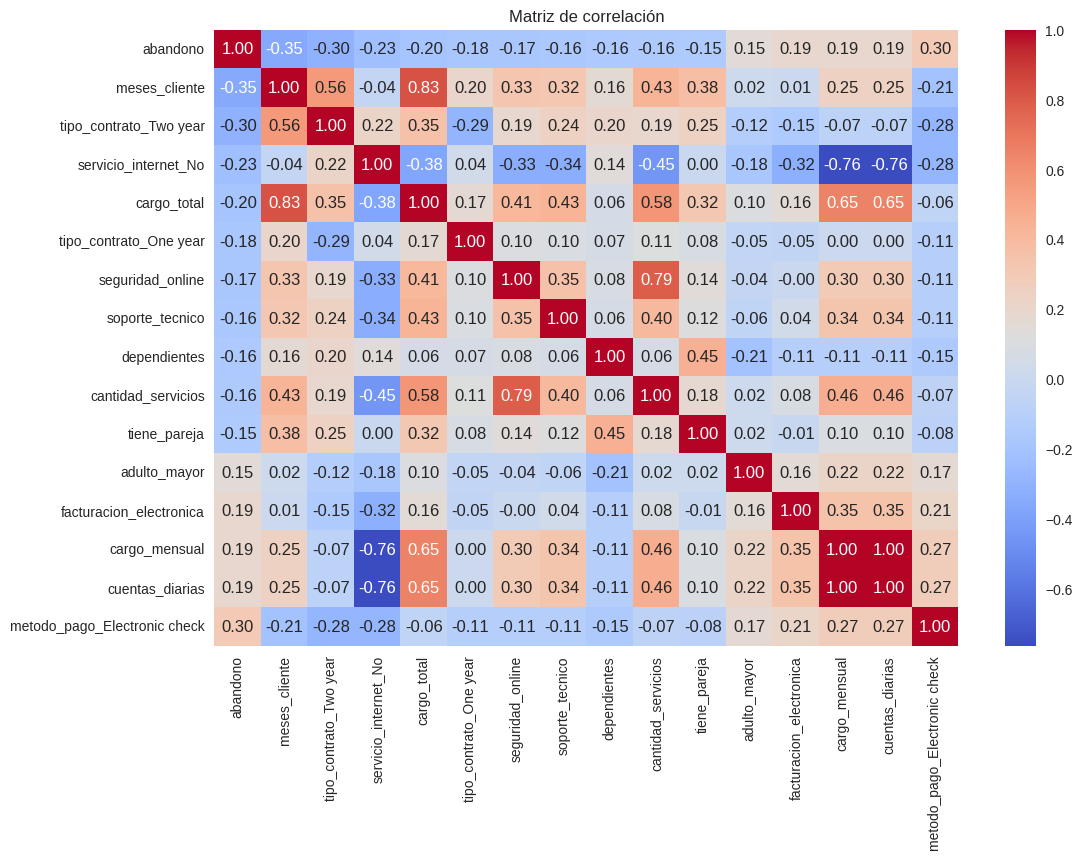

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df_modelo.corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de correlación")
plt.show()

Se analizó la matriz de correlación entre las variables numéricas para identificar relaciones relevantes con la variable objetivo abandono. Los resultados muestran que algunas variables presentan asociaciones importantes con la cancelación del servicio.

En particular, variables como cargo_mensual, cuentas_diarias y el método de pago Electronic Check presentan correlaciones positivas con el abandono, lo que sugiere que clientes con mayores cargos o ciertos métodos de pago podrían tener mayor probabilidad de cancelar.

Por otro lado, variables como meses_cliente y contratos de mayor duración presentan correlaciones negativas, indicando que clientes con mayor antigüedad o contratos más largos tienden a permanecer en el servicio.

Estos hallazgos permiten identificar variables relevantes que pueden ser utilizadas como predictores en los modelos de Machine Learning

In [ ]:
#Segmentar variables
X = df_modelo.drop('abandono', axis=1)
y = df_modelo['abandono']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

modelo = RandomForestClassifier(random_state=42)

modelo.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
import pandas as pd

importancias = pd.DataFrame({
    'variable': X.columns,
    'importancia': modelo.feature_importances_
})

importancias = importancias.sort_values(by='importancia', ascending=False)

importancias

,variable,importancia
3,cargo_total,0.197902
12,cargo_mensual,0.184561
0,meses_cliente,0.173232
13,cuentas_diarias,0.152337
14,metodo_pago_Electronic check,0.047846
1,tipo_contrato_Two year,0.038501
8,cantidad_servicios,0.030565
4,tipo_contrato_One year,0.027990
11,facturacion_electronica,0.025021
6,soporte_tecnico,0.024185


##Análisis Dirigido

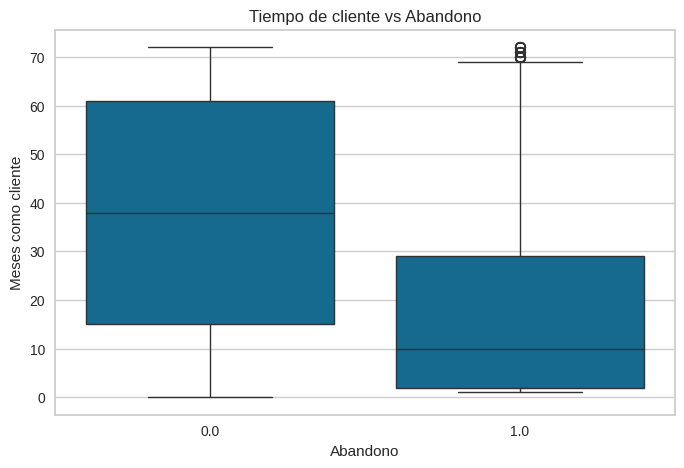

In [ ]:
# Tiempo de contrato (meses_cliente) vs Cancelación
plt.figure(figsize=(8,5))

sns.boxplot(
    x='abandono',
    y='meses_cliente',
    data=df_modelo
)

plt.title('Tiempo de cliente vs Abandono')
plt.xlabel('Abandono')
plt.ylabel('Meses como cliente')

plt.show()

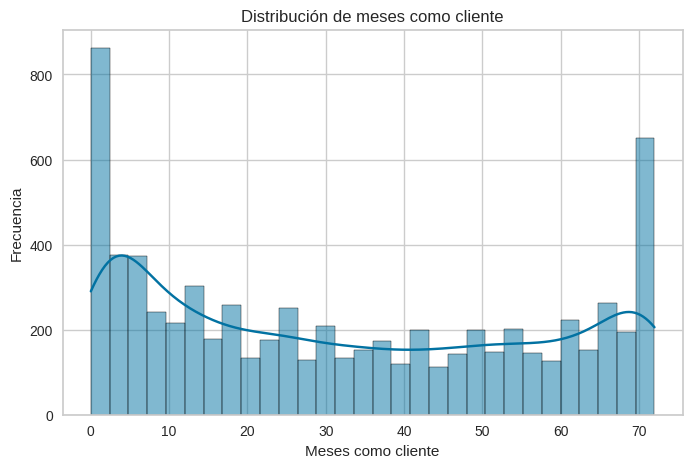

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.histplot(
    data=df_modelo,
    x='meses_cliente',
    bins=30,
    kde=True
)

plt.title('Distribución de meses como cliente')
plt.xlabel('Meses como cliente')
plt.ylabel('Frecuencia')

plt.show()

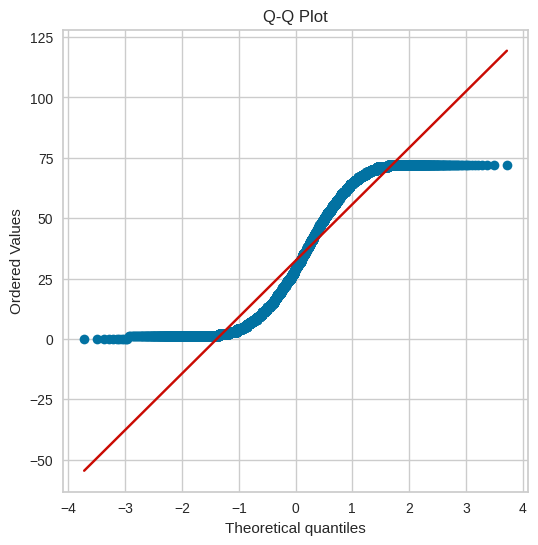

In [ ]:
# Ver distribucion normal en los datos
import scipy.stats as stats

plt.figure(figsize=(6,6))
stats.probplot(df_modelo['meses_cliente'], dist="norm", plot=plt)
plt.title("Q-Q Plot")
plt.show()

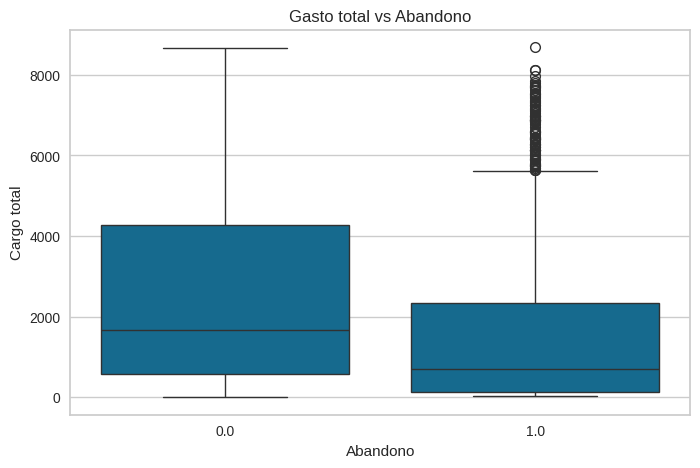

In [ ]:
# Gasto total vs Cancelación
plt.figure(figsize=(8,5))

sns.boxplot(
    x='abandono',
    y='cargo_total',
    data=df_modelo
)

plt.title('Gasto total vs Abandono')
plt.xlabel('Abandono')
plt.ylabel('Cargo total')

plt.show()

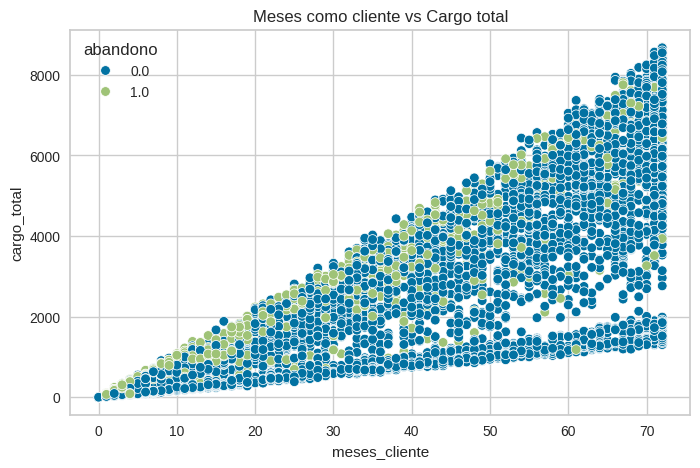

In [ ]:
#Scatter plot
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='meses_cliente',
    y='cargo_total',
    hue='abandono',
    data=df_modelo
)

plt.title('Meses como cliente vs Cargo total')
plt.show()

El análisis de las variables numéricas muestra patrones claros asociados con la cancelación del servicio. Los clientes que abandonaron presentan una menor antigüedad promedio en la empresa, lo que indica que el riesgo de churn es mayor durante los primeros meses de servicio.

Asimismo, los clientes que cancelaron tienden a tener un gasto total menor, lo que sugiere que muchos abandonan antes de convertirse en clientes de alto valor para la empresa.

El gráfico de dispersión entre meses como cliente y gasto total muestra que los clientes con menor tiempo en la empresa se concentran en niveles de gasto más bajos y presentan mayores tasas de cancelación.

#🤖 Modelado Predictivo

##Separación de Datos

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y

##Creación de Modelos

In [ ]:
# Normalizar datos (solo para Regresión Logística)
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

###Baseline

In [ ]:
from sklearn.dummy import DummyRegressor
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42
)


baseline = DummyRegressor(strategy='mean')
baseline.fit(X_train, y_train)

DummyRegressor()

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

y_pred_baseline = baseline.predict(X_test)

def calcular_regresion(y_test, y_pred):
  rmse = mean_squared_error(y_test, y_pred)
  mae = mean_absolute_error(y_test, y_pred)
  r2 = baseline.score(X_test, y_test)
  metricas = {
      'RMSE': round(rmse**(1/2), 4),
      'MAE': round(mae, 4),
      'R2': round(r2, 4)
  }
  return metricas

In [ ]:
resultado_baseline = calcular_regresion(y_test, y_pred_baseline)
resultado_baseline

{'RMSE': 0.4391, 'MAE': 0.3887, 'R2': -0.0002}

#Modelo Random Forest

In [ ]:
from sklearn.ensemble import RandomForestRegressor

modelo = RandomForestRegressor(max_depth=5, random_state=42)
modelo.fit(X_train, y_train)
ypred = modelo.predict(X_test)
resultados_rf = calcular_regresion(y_test,ypred)
resultados_rf

{'RMSE': 0.3727, 'MAE': 0.2796, 'R2': -0.0002}

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


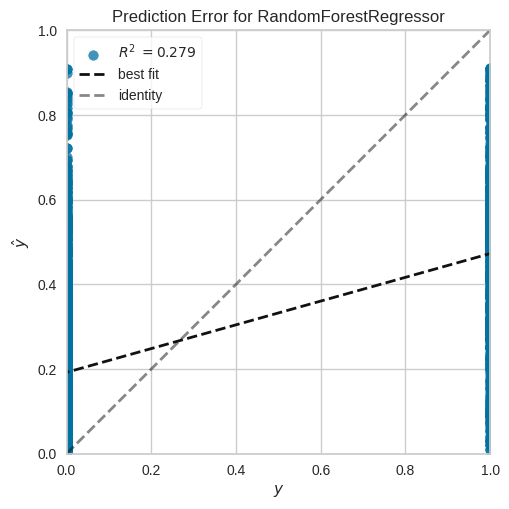

In [ ]:
# Vizualizar el moldelo
from yellowbrick.regressor import prediction_error
visualizer = prediction_error(modelo, X_train, y_train, X_test, y_test);

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


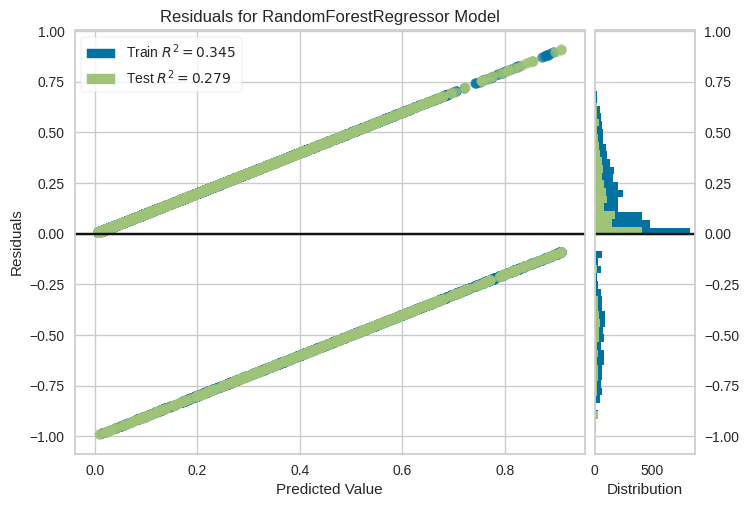

In [ ]:
# Gráfico de residuos
from yellowbrick.regressor import residuals_plot
viz = residuals_plot(modelo, X_train, y_train, X_test, y_test)

##Validación Cruzada

In [ ]:
from sklearn.model_selection import KFold, cross_validate
scoring={
    'RMSE':'neg_root_mean_squared_error',
    'MAE': 'neg_mean_absolute_error',
    'R2': 'r2'
    }

cv = KFold(n_splits=5, shuffle=True, random_state=42)
cv_results = cross_validate(modelo, X_train, y_train, cv=cv, scoring=scoring)
cv_results

{'fit_time': array([0.65490174, 0.65955067, 0.63805151, 0.65942216, 0.7333405 ]),
 'score_time': array([0.01619148, 0.01430249, 0.01404619, 0.01405382, 0.0225544 ]),
 'test_RMSE': array([-0.36914381, -0.37872083, -0.36811071, -0.3675907 , -0.37851426]),
 'test_MAE': array([-0.27519291, -0.28224627, -0.27861624, -0.27929503, -0.28335945]),
 'test_R2': array([0.32395194, 0.26843808, 0.26419848, 0.31245405, 0.28440691])}

In [ ]:
print(f'Modelo random forest: {resultados_rf}')

Modelo random forest: {'RMSE': 0.3727, 'MAE': 0.2796, 'R2': -0.0002}


##Feature importances

In [ ]:
Importances=modelo.feature_importances_
Importances

array([0.38783454, 0.07597896, 0.04351306, 0.06187106, 0.04290363,
       0.00874304, 0.00980475, 0.00132126, 0.0115481 , 0.00046241,
       0.00486528, 0.00806282, 0.20698687, 0.04891217, 0.08719206])

In [ ]:
feature_importances = pd.DataFrame({'Features':X.columns, 'Importances':(Importances*100).round(2)}).sort_values('Importances', ascending=False)
feature_importances

,Features,Importances
0,meses_cliente,38.78
12,cargo_mensual,20.70
14,metodo_pago_Electronic check,8.72
1,tipo_contrato_Two year,7.60
3,cargo_total,6.19
13,cuentas_diarias,4.89
2,servicio_internet_No,4.35
4,tipo_contrato_One year,4.29
8,cantidad_servicios,1.15
6,soporte_tecnico,0.98


In [ ]:
resultados = pd.DataFrame(index=['RMSE','MAE','R2'])
model_feacture = RandomForestRegressor(max_depth=5, random_state=42)
ct_feactures = [i if i != 0 else 1 for i in range(0,35,5)]
#ct_feactures =(1,5)

for i in ct_feactures:
  selected_feactures = feature_importances['Features'].values[:i]
  X_train_sel = X_train[selected_feactures]
  X_test_sel = X_test[selected_feactures]
  model_feacture.fit(X_train_sel, y_train)
  ypred_sel = model_feacture.predict(X_test_sel)
  metricas = calcular_regresion(y_test, ypred_sel)
  resultados[i] = list(metricas.values())

resultados

,1,5,10,15,20,25,30
RMSE,0.4110,0.3779,0.3745,0.3727,0.3727,0.3727,0.3727
MAE,0.3353,0.2841,0.2807,0.2796,0.2796,0.2796,0.2796
R2,-0.0002,-0.0002,-0.0002,-0.0002,-0.0002,-0.0002,-0.0002


In [112]:
# Seleccionar variables importantes
# values[:13] cantidad de variables
selected_features = feature_importances['Features'].values[:5]
X_selected_features = X[selected_features]
X_selected_features

,meses_cliente,cargo_mensual,metodo_pago_Electronic check,tipo_contrato_Two year,cargo_total
0,9,65.60,0,0,593.30
1,9,59.90,0,0,542.40
2,4,73.90,1,0,280.85
3,13,98.00,1,0,1237.85
4,3,83.90,0,0,267.40
...,...,...,...,...,...
7262,13,55.15,0,0,742.90
7263,22,85.10,1,0,1873.70
7264,2,50.30,0,0,92.75
7265,67,67.85,0,1,4627.65


##hiperparámetros con GridSearchCV

In [113]:
param_grid = {
    'max_depth': [5,10,15],
    'min_samples_leaf': [1,2,3],
    'min_samples_split': [2,4,6],
    'n_estimators':[100,150,200]
}

In [117]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, GridSearchCV

cv = KFold(n_splits=5, shuffle=True, random_state=42)
model_grid = GridSearchCV(RandomForestRegressor(random_state=42), param_grid = param_grid, scoring='r2',
                          cv=cv)
model_grid.fit(X_train, y_train)

GridSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
             estimator=RandomForestRegressor(random_state=42),
             param_grid={'max_depth': [5, 10, 15],
                         'min_samples_leaf': [1, 2, 3],
                         'min_samples_split': [2, 4, 6],
                         'n_estimators': [100, 150, 200]},
             scoring='r2')

In [118]:
# LOS MEJORES PARAMETROS
model_grid.best_params_

{'max_depth': 5,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'n_estimators': 150}

In [120]:
# VAMOS A VER COMO PREDIJO
y_pred_grid = model_grid.predict(X_test)
metricas_model_grid = calcular_regresion(y_test, y_pred_grid)
metricas_model_grid

{'RMSE': 0.3731, 'MAE': 0.28, 'R2': -0.0002}

In [109]:
resultados['model_grid'] = list(metricas_model_grid.values())

##Evaluar el modelo

Para evaluar el desempeño del modelo de predicción de abandono se utilizaron métricas de clasificación como accuracy, precision, recall, F1-score y ROC-AUC. Estas métricas permiten analizar no solo el porcentaje de predicciones correctas, sino también la capacidad del modelo para identificar correctamente a los clientes con riesgo de cancelación. En problemas de churn, el recall es particularmente importante, ya que permite detectar la mayor cantidad posible de clientes que podrían abandonar el servicio.

In [123]:
from sklearn.metrics import classification_report
import numpy as np

# Convert continuous predictions to binary predictions using a threshold (e.g., 0.5)
y_pred_grid_binary = np.where(y_pred_grid > 0.5, 1, 0)

print(classification_report(y_test, y_pred_grid_binary))

              precision    recall  f1-score   support

         0.0       0.83      0.91      0.87      1562
         1.0       0.66      0.48      0.56       551

    accuracy                           0.80      2113
   macro avg       0.74      0.70      0.71      2113
weighted avg       0.79      0.80      0.79      2113



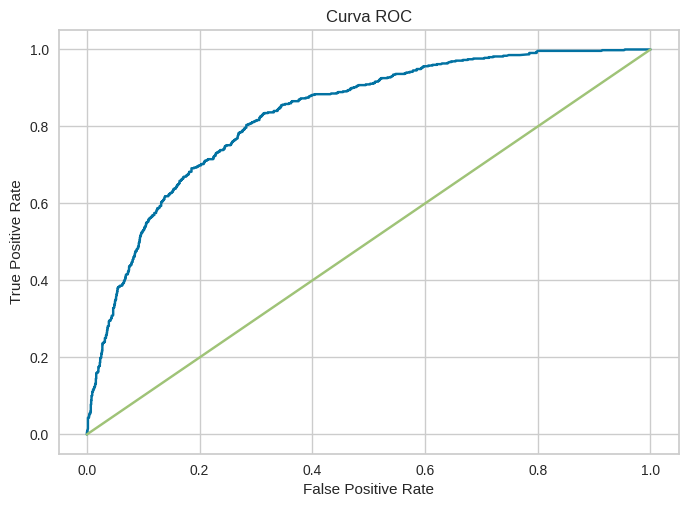

In [124]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_pred_grid)

plt.plot(fpr, tpr)
plt.plot([0,1],[0,1])

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC")

plt.show()

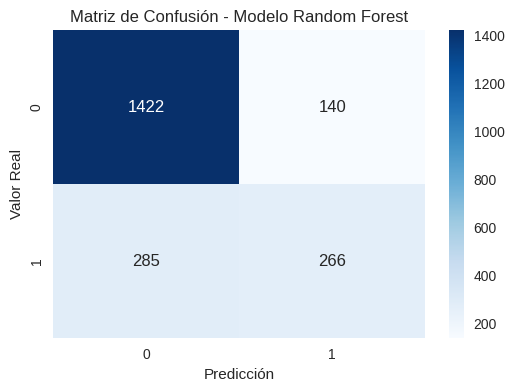

In [126]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Convert continuous predictions to binary predictions using a threshold (e.g., 0.5)
y_pred_grid_binary = np.where(y_pred_grid > 0.5, 1, 0)

cm = confusion_matrix(y_test, y_pred_grid_binary)

plt.figure(figsize=(6,4))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Matriz de Confusión - Modelo Random Forest")
plt.xlabel("Predicción")
plt.ylabel("Valor Real")

plt.show()

La matriz de confusión muestra que el modelo Random Forest logra identificar correctamente la mayoría de los clientes que permanecen en la empresa (1422 casos). Sin embargo, el modelo tiene más dificultades para detectar clientes que abandonan el servicio. De los clientes que realmente cancelaron, el modelo identificó correctamente 266, mientras que 285 no fueron detectados (falsos negativos). Esto indica que el modelo tiene un rendimiento aceptable, pero aún existe margen de mejora para aumentar la detección de clientes con riesgo de cancelación.

# Modelo Regresión Logística

In [134]:
# Estandarizar los datos
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [135]:
# Crear el modelo de regresión logística
from sklearn.linear_model import LogisticRegression

modelo_lr = LogisticRegression()

modelo_lr.fit(X_train_scaled, y_train)

LogisticRegression()

In [140]:
modelo_lr = LogisticRegression(class_weight='balanced')
modelo_lr.fit(X_train_scaled, y_train)

LogisticRegression(class_weight='balanced')

In [141]:
# Hacer predicciones
y_pred_lr = modelo_lr.predict(X_test_scaled)

In [131]:
#Evaluar el modelo
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

         0.0       0.86      0.90      0.88      1562
         1.0       0.66      0.57      0.61       551

    accuracy                           0.81      2113
   macro avg       0.76      0.73      0.74      2113
weighted avg       0.80      0.81      0.81      2113



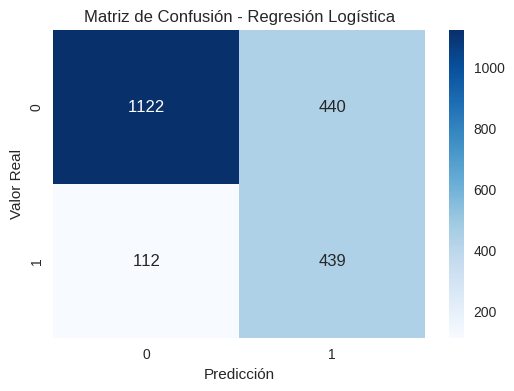

In [142]:
# Matriz de confusión
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Matriz de Confusión - Regresión Logística")
plt.xlabel("Predicción")
plt.ylabel("Valor Real")

plt.show()

El modelo de Regresión Logística mostró una mayor capacidad para detectar clientes con riesgo de cancelación en comparación con el modelo Random Forest. La matriz de confusión indica que el modelo logra identificar correctamente 439 clientes que abandonaron el servicio, con un recall cercano al 80%. Esto significa que el modelo es capaz de detectar la mayoría de los clientes con riesgo de churn, lo cual resulta especialmente valioso para implementar estrategias de retención.

#Análisis de la Importancia de las Variables

Se analizó la importancia de las variables utilizando dos enfoques. En el modelo de Regresión Logística se examinaron los coeficientes asociados a cada variable, los cuales indican cómo influyen en la probabilidad de cancelación. Los coeficientes positivos aumentan la probabilidad de churn, mientras que los negativos la reducen.

En el modelo Random Forest se utilizó la métrica de importancia de variables basada en la reducción de impureza en los árboles de decisión. Este método permite identificar qué variables contribuyen más a la capacidad predictiva del modelo.

Los resultados muestran que variables como el gasto mensual, el tipo de contrato y el tiempo como cliente tienen una fuerte relación con la cancelación del servicio.

##Importancia de variables en Random Forest

In [145]:
importances = modelo_rf.feature_importances_

importancia_rf = pd.DataFrame({
    'Variable': X.columns,
    'Importancia': importances
})

importancia_rf = importancia_rf.sort_values(by='Importancia', ascending=False)

importancia_rf

,Variable,Importancia
3,cargo_total,0.206469
12,cargo_mensual,0.180411
0,meses_cliente,0.171460
13,cuentas_diarias,0.153216
14,metodo_pago_Electronic check,0.044923
1,tipo_contrato_Two year,0.037098
8,cantidad_servicios,0.029829
11,facturacion_electronica,0.026287
4,tipo_contrato_One year,0.025819
6,soporte_tecnico,0.023903


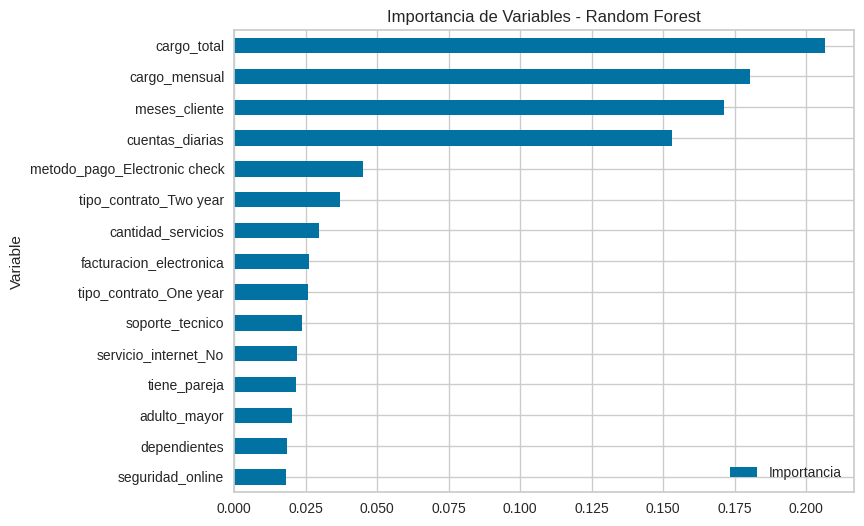

In [146]:
importancia_rf.sort_values(by='Importancia').plot(
    x='Variable',
    y='Importancia',
    kind='barh',
    figsize=(8,6)
)

plt.title("Importancia de Variables - Random Forest")

plt.show()

Este gráfico muestra qué variables ayudan más al modelo a predecir el abandono. Las más importantes son:

Variables más influyentes

1. cargo_total
2. cargo_mensual
3. meses_cliente
4. cuentas_diarias

Esto significa que el comportamiento financiero del cliente es el principal factor de churn.

Interpretación:

* clientes que pagan más tienden a abandonar más

* clientes con menos tiempo en la empresa tienen mayor riesgo

* el nivel de gasto diario también influye

##Importancia de variables en Regresión Logística

In [143]:
import pandas as pd

coeficientes = pd.DataFrame({
    'Variable': X.columns,
    'Coeficiente': modelo_lr.coef_[0]
})

coeficientes = coeficientes.sort_values(by='Coeficiente', ascending=False)

coeficientes

,Variable,Coeficiente
3,cargo_total,0.820804
14,metodo_pago_Electronic check,0.213682
13,cuentas_diarias,0.185039
12,cargo_mensual,0.178112
11,facturacion_electronica,0.154965
10,adulto_mayor,0.087003
9,tiene_pareja,0.011867
7,dependientes,-0.064629
5,seguridad_online,-0.073137
8,cantidad_servicios,-0.186176


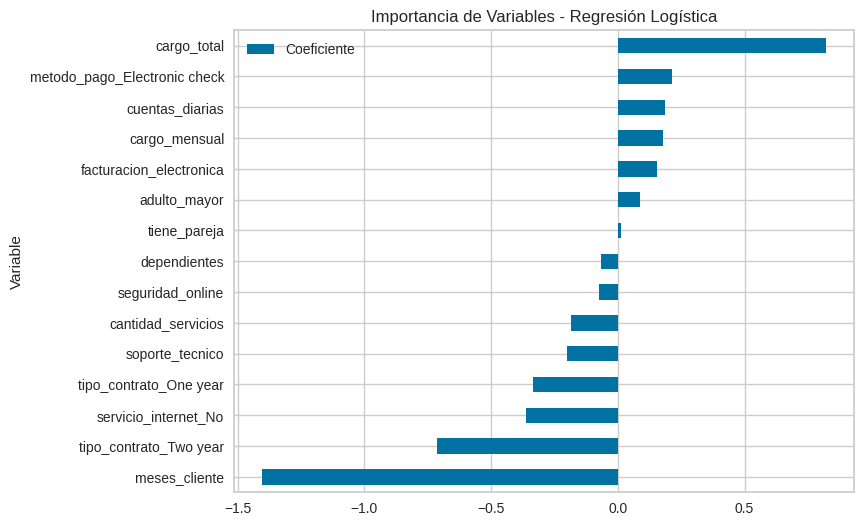

In [144]:
import matplotlib.pyplot as plt

coeficientes.sort_values(by='Coeficiente').plot(
    x='Variable',
    y='Coeficiente',
    kind='barh',
    figsize=(8,6)
)

plt.title("Importancia de Variables - Regresión Logística")

plt.show()

**Variables que aumentan la probabilidad de abandono**

Las más importantes son:

1. cargo_total

* Clientes con mayor gasto total tienen mayor probabilidad de abandonar.

2. metodo_pago_Electronic check

* Este método de pago está fuertemente asociado con churn.

3. cuentas_diarias

* Más gasto diario puede indicar clientes con planes más caros, lo que aumenta la probabilidad de cancelación.

4. cargo_mensual

* Clientes con facturas más altas tienen mayor riesgo de abandono.

**Variables que reducen el abandono**

Las más importantes:

1. meses_cliente

* Esta es la variable más fuerte del modelo.

* Clientes con más tiempo en la empresa tienen menos probabilidad de abandonar.

* Esto se conoce como efecto de fidelización.

2. tipo_contrato_Two year

* Los contratos de dos años reducen fuertemente el churn.

* Esto indica que los contratos largos fidelizan clientes.

3. servicio_internet_No

* Clientes sin internet tienen menor probabilidad de abandonar.

4. tipo_contrato_One year

* Los contratos anuales también reducen el abandono.



## Conclusión
El análisis de importancia de variables muestra que los factores financieros y de relación con el cliente son los principales determinantes del abandono. Variables como el gasto mensual, el gasto total y el tiempo como cliente tienen un impacto significativo en la predicción de churn.

Además, el tipo de contrato juega un rol importante, ya que los contratos de mayor duración reducen la probabilidad de cancelación. También se observa que el método de pago mediante "Electronic Check" está asociado con una mayor probabilidad de abandono.

En general, los resultados sugieren que los clientes con menor antigüedad y mayores costos de servicio presentan un mayor riesgo de cancelar sus servicios.

#Informe de Análisis Predictivo de Cancelación de Clientes (Churn)

##1. Introducción

El objetivo de este análisis fue desarrollar modelos predictivos capaces de identificar clientes con alta probabilidad de cancelar sus servicios en Telecom X. La cancelación de clientes (churn) representa un problema relevante para las empresas de telecomunicaciones, ya que implica pérdida de ingresos y mayores costos de adquisición de nuevos clientes.

Para abordar este problema se realizó un proceso de preparación de datos, análisis exploratorio, selección de variables y construcción de modelos de Machine Learning que permitieran anticipar el abandono de clientes y comprender los factores que influyen en esta decisión.

##2. Modelos Predictivos Utilizados

Se implementaron dos modelos de clasificación para predecir la cancelación de clientes:

**Random Forest**

Este modelo basado en árboles de decisión permite capturar relaciones no lineales entre las variables y es robusto frente a datos complejos. Su principal ventaja es la capacidad de identificar la importancia de las variables mediante la reducción de impureza en los árboles.

**Regresión Logística**

Este modelo estadístico permite interpretar con claridad el impacto de cada variable sobre la probabilidad de cancelación. Para su implementación se realizó una estandarización de las variables numéricas para mejorar el rendimiento del modelo.

##3. Evaluación del Rendimiento de los Modelos

El modelo Random Forest mostró una mayor precisión general (accuracy), mientras que la Regresión Logística demostró una mayor capacidad para detectar clientes que efectivamente cancelan el servicio (mayor recall).

En problemas de churn, detectar clientes con riesgo de cancelación es especialmente importante, ya que permite a la empresa implementar estrategias de retención de manera anticipada. En este sentido, el modelo de Regresión Logística resultó particularmente útil para identificar clientes con alta probabilidad de abandono.

##4. Factores que Influyen en la Cancelación

El análisis de importancia de variables permitió identificar los factores más relevantes asociados al abandono de clientes.

Los resultados de ambos modelos muestran que los factores financieros y la relación del cliente con la empresa tienen un impacto significativo en la cancelación.

**Variables con mayor impacto en el abandono**

**Cargo total y cargo mensual**

Los clientes con mayores costos mensuales y mayor gasto acumulado presentan una mayor probabilidad de cancelar el servicio. Esto sugiere que los planes más costosos pueden generar mayor insatisfacción o percepción de alto precio.

**Tiempo como cliente (meses_cliente)**

El tiempo de permanencia en la empresa es uno de los factores más importantes. Los clientes con menor antigüedad presentan un mayor riesgo de cancelar el servicio, mientras que los clientes con mayor tiempo tienden a permanecer en la empresa.

**Método de pago Electronic Check**

El método de pago mediante cheque electrónico aparece asociado con una mayor probabilidad de abandono, lo que podría indicar una menor fidelización o mayor facilidad para cancelar el servicio.

**Tipo de contrato**
Los contratos de mayor duración, especialmente los contratos de dos años, reducen significativamente la probabilidad de cancelación. Esto indica que los contratos de largo plazo generan mayor estabilidad en la relación con el cliente.

##5. Principales Insights del Análisis

A partir del análisis realizado se pueden identificar varios patrones relevantes:

* Los clientes con poco tiempo en la empresa presentan mayor riesgo de abandono.

* Los planes con mayor costo mensual están asociados a una mayor probabilidad de cancelación.

* Los clientes con contratos mensuales son más propensos a abandonar en comparación con aquellos con contratos anuales o de dos años.

* El método de pago Electronic Check muestra una mayor relación con la cancelación de clientes.

En general, el comportamiento financiero y el tipo de relación contractual tienen un mayor impacto en el abandono que las características demográficas de los clientes.

##6. Estrategias de Retención Propuestas

Basándose en los resultados obtenidos, se proponen las siguientes estrategias para reducir la cancelación de clientes:

**Programas de fidelización para clientes nuevos**

Dado que los clientes con menor antigüedad presentan mayor probabilidad de abandono, se podrían implementar incentivos durante los primeros meses del servicio para fortalecer la relación con la empresa.

**Incentivar contratos de mayor duración**

Promover contratos anuales o de dos años mediante descuentos o beneficios adicionales podría aumentar la permanencia de los clientes.

**Revisión de planes con altos costos mensuales**

Los clientes con cargos mensuales elevados presentan mayor probabilidad de cancelación, por lo que se podrían ofrecer planes más flexibles o promociones específicas para este segmento.

**Análisis del método de pago**
Dado que el método de pago Electronic Check está asociado a mayor churn, se podrían incentivar otros métodos de pago automáticos que favorezcan la permanencia del cliente.



##7. Conclusión

El análisis predictivo permitió identificar los principales factores asociados al abandono de clientes en Telecom X. Los resultados muestran que variables relacionadas con el costo del servicio, el tiempo de permanencia y el tipo de contrato tienen una influencia significativa en la cancelación.

Los modelos desarrollados permiten anticipar qué clientes tienen mayor probabilidad de abandonar el servicio, lo que abre la posibilidad de implementar estrategias de retención más efectivas y basadas en datos.

La aplicación de estos modelos y estrategias podría contribuir a reducir la tasa de cancelación, mejorar la fidelización de los clientes y fortalecer la sostenibilidad del negocio en el largo plazo.